In [1]:
#optimized search algorithm with GUI - Result of 1st Sprint
#

import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from collections import deque
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk

def trace_boundary(binary_image):
    """Finds and traces all boundary pixels in a binary image using BFS with 8-connectivity."""
    start_time = time.time()
    
    h, w = binary_image.shape
    boundary_mask = np.zeros((h, w), dtype=np.uint8)  # 0 = not boundary, 255 = boundary
    visited = np.zeros((h, w), dtype=bool)  # Track visited pixels
    labels = np.zeros((h, w), dtype=int)  # Store labels of each boundary pixel
    current_label = 1  # Start labeling from 1

    row_sums = np.sum(binary_image, axis=1)
    col_sums = np.sum(binary_image, axis=0)
    
    top = np.argmax(row_sums > 0)
    bottom = h - np.argmax(row_sums[::-1] > 0)
    left = np.argmax(col_sums > 0)
    right = w - np.argmax(col_sums[::-1] > 0)
    
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

    def bfs(start_i, start_j):
        queue = deque([(start_i, start_j)])
        
        while queue:
            i, j = queue.popleft()
            
            if visited[i, j]:
                continue
            
            visited[i, j] = True
            boundary_mask[i, j] = 255
            labels[i, j] = current_label

            for dx, dy in directions:
                ni, nj = i + dx, j + dy
                if 0 <= ni < h and 0 <= nj < w and not visited[ni, nj]:
                    if binary_image[ni, nj] == 255:
                        boundary_found = any(0 <= ni + dx2 < h and 0 <= nj + dy2 < w and binary_image[ni + dx2, nj + dy2] == 0 for dx2, dy2 in directions)
                        if boundary_found:
                            queue.append((ni, nj))
    
    for i in range(top, bottom):
        for j in range(left, right):
            if binary_image[i, j] == 255 and not visited[i, j]:
                if any(0 <= i + dx < h and 0 <= j + dy < w and binary_image[i + dx, j + dy] == 0 for dx, dy in directions):
                    bfs(i, j)
                    current_label += 1

    print("--- %s seconds ---" % (time.time() - start_time))
    return boundary_mask, labels, current_label - 1


def compute_circularity(labels, num_labels):
    circularities = {}

    for label in range(1, num_labels + 1):
        # Get coordinates of all pixels with this label
        coords = np.column_stack(np.where(labels == label))
        
        if coords.shape[0] < 2:
            continue  # Skip tiny components
        
        # Compute centroid
        centroid = np.mean(coords, axis=0)

        # Compute Euclidean distances to centroid
        distances = np.linalg.norm(coords - centroid, axis=1)

        # Compute mean and variance
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)

        # Avoid division by zero
        circularity = mean_dist / std_dist if std_dist != 0 else 0

        circularities[label] = circularity

    return circularities

def process_image():
    image_path = entry_path.get()
    erosion_iters = int(entry_iterations.get())
    border_thickness = int(entry_thickness.get())
    
    beans_img = cv2.imread(image_path)
    img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)
    
    height, width = img_gray.shape
    border_x = int(height * 0.02)
    border_y = int(width * 0.02)
    img_cropped = img_gray[border_x:height-border_x, border_y:width-border_y]
    
    threshold = 75
    _, img_segmented = cv2.threshold(img_cropped, threshold, 255, cv2.THRESH_BINARY_INV)
    
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    img_eroded = cv2.erode(img_segmented, kernel_erode, iterations=erosion_iters)
    
    kernel_open = np.ones((3,3), np.uint8)
    img_opened = cv2.morphologyEx(img_eroded, cv2.MORPH_OPEN, kernel_open)
    
    boundary_mask, labels, num_labels = trace_boundary(img_opened)
    colored_img = cv2.cvtColor(img_opened, cv2.COLOR_GRAY2BGR)
    boundary_mask, labels, num_labels = trace_boundary(img_opened)
    circularities = compute_circularity(labels, num_labels)
    print("Circularities per label:", circularities)
    
    for i in range(border_thickness):
        dilated_mask = cv2.dilate(boundary_mask, np.ones((3,3), np.uint8), iterations=i)
        colored_img[dilated_mask == 255] = [0, 0, 255]
    
    img_original = Image.open(image_path)
    img_original.thumbnail((250, 250))
    img_tk = ImageTk.PhotoImage(img_original)
    label_original.config(image=img_tk)
    label_original.image = img_tk
    
    img_result = Image.fromarray(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
    img_result.thumbnail((250, 250))
    img_result_tk = ImageTk.PhotoImage(img_result)
    label_result.config(image=img_result_tk)
    label_result.image = img_result_tk
    
    label_count.config(text=f"Boundaries found: {num_labels}")





def select_file():
    filename = filedialog.askopenfilename()
    entry_path.delete(0, tk.END)
    entry_path.insert(0, filename)






root = tk.Tk()
root.geometry("600x400")
root.title("Boundary Detection GUI")

frame_controls = tk.Frame(root)
frame_controls.pack()

label_path = tk.Label(frame_controls, text="Image Path:")
label_path.grid(row=0, column=0)
entry_path = tk.Entry(frame_controls, width=50)
entry_path.grid(row=0, column=1)
entry_path.insert(0, "../imgs/chick_2.bmp")
btn_browse = tk.Button(frame_controls, text="Browse", command=select_file)
btn_browse.grid(row=0, column=2)

label_iterations = tk.Label(frame_controls, text="Erosion Iterations:")
label_iterations.grid(row=1, column=0)
entry_iterations = tk.Entry(frame_controls, width=10)
entry_iterations.grid(row=1, column=1)
entry_iterations.insert(0, "15")

label_thickness = tk.Label(frame_controls, text="Border Thickness:")
label_thickness.grid(row=2, column=0)
entry_thickness = tk.Entry(frame_controls, width=10)
entry_thickness.grid(row=2, column=1)
entry_thickness.insert(0, "1")

btn_process = tk.Button(root, text="Process Image", command=process_image)
btn_process.pack()

frame_images = tk.Frame(root)
frame_images.pack()

label_original = tk.Label(frame_images)
label_original.pack(side=tk.LEFT)

label_result = tk.Label(frame_images)
label_result.pack(side=tk.RIGHT)

label_count = tk.Label(root, text="")
label_count.pack()

root.mainloop()






--- 0.025049686431884766 seconds ---
--- 0.024857759475708008 seconds ---
Circularities per label: {1: np.float64(7.053609568621824)}


Mean of Beans: 2.9903422284548045
Variance of Beans: 0.1063376662949815
Mean of Chickpeas: 8.147293757147533
Variance of Chickpeas: 3.2772358381253825


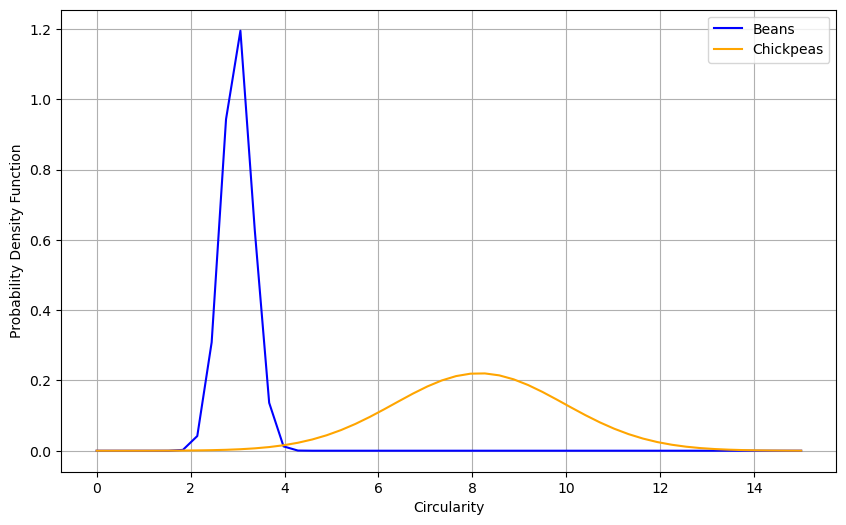

Mean of Beans with ratio of Minor to Major Axis: 0.35699999999999993
Variance of Beans with ratio of Minor to Major Axis: 0.0023209999999999993
Mean of Chickpeas with ratio of Minor to Major Axis: 0.7422222222222222
Variance of Chickpeas with ratio of Minor to Major Axis: 0.00386172839506173


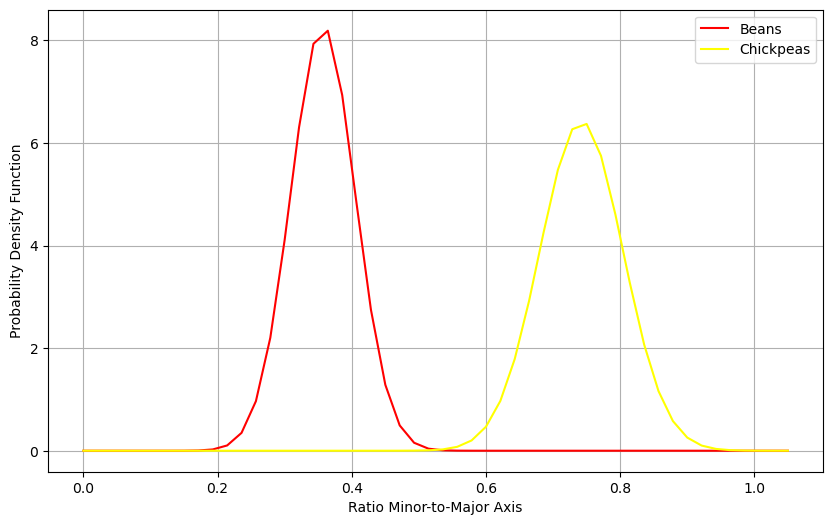

In [9]:
#Calculating the Features Probability Density Functions

import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

circ_beans = np.array([
3.093879994066079,
2.9552764866528953,
2.8105062918903263,
3.0060812043697087,
2.8426192786312945,
2.7114768054467104,
2.6336501477404246,
2.9622526026058926,
3.0080002781506487,
3.8796791949940683
])

circ_chick = np.array([
7.596558513360611,
7.665275555252748,
8.075975474386714,
11.307972535715813,
5.602601767730886,
5.394534672391477,
7.915273838301105,
10.898128562229129,
8.90010073382596,
8.11651591828087,
])

mean_beans_circ = np.mean(circ_beans)
var_beans_circ = np.var(circ_beans)
std_beans_circ = np.std(circ_beans)
print('Mean of Beans:', mean_beans_circ)
print('Variance of Beans:', var_beans_circ)

mean_chick_circ = np.mean(circ_chick)
var_chick_circ = np.var(circ_chick)
std_chick_circ = np.std(circ_chick)
print('Mean of Chickpeas:', mean_chick_circ)
print('Variance of Chickpeas:', var_chick_circ)

x = np.linspace(0, 15)
# Normalverteilungsdichten berechnen
pdf_beans = norm.pdf(x, mean_beans_circ, std_beans_circ)
pdf_chick = norm.pdf(x, mean_chick_circ, std_chick_circ)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_beans, label='Beans', color='blue')
plt.plot(x, pdf_chick, label='Chickpeas', color='orange')
plt.xlabel('Circularity')
plt.ylabel('Probability Density Function')
plt.legend()
plt.grid(True)
plt.show()


ratio_min_maj_beans = np.array([
0.37,
0.34,
0.33,
0.36,
0.33,
0.32,
0.31,
0.36,
0.36,
0.49
])

ratio_min_maj_chick = np.array([
0.7,
0.68,
0.77,
0.79,
0.61,
0.76,
0.82,
0.78,
0.77
])


mean_beans = np.mean(ratio_min_maj_beans)
var_beans = np.var(ratio_min_maj_beans)
std_beans = np.std(ratio_min_maj_beans)
print('Mean of Beans with ratio of Minor to Major Axis:', mean_beans)
print('Variance of Beans with ratio of Minor to Major Axis:', var_beans)

mean_chick = np.mean(ratio_min_maj_chick)
var_chick = np.var(ratio_min_maj_chick)
std_chick = np.std(ratio_min_maj_chick)
print('Mean of Chickpeas with ratio of Minor to Major Axis:', mean_chick)
print('Variance of Chickpeas with ratio of Minor to Major Axis:', var_chick)

x = np.linspace(0, 1.05)
# Normalverteilungsdichten berechnen
pdf_beans = norm.pdf(x, mean_beans, std_beans)
pdf_chick = norm.pdf(x, mean_chick, std_chick)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_beans, label='Beans', color='red')
plt.plot(x, pdf_chick, label='Chickpeas', color='yellow')
plt.xlabel('Ratio Minor-to-Major Axis')
plt.ylabel('Probability Density Function')
plt.legend()
plt.grid(True)


plt.show()


In [ ]:
# Calculating the probability if an object is an chickpea or a bean 
# based on Bayes Theorem and the Feature Ratio of Minor-to-Major Axis

p_class_beans = 0.5
p_class_chick = 0.5


def object_classification_min_maj_axis(ratio_min_maj_axis):

    p_obj_bean = norm.pdf(ratio_min_maj_axis, mean_beans, std_beans)
    p_obj_chick = norm.pdf(ratio_min_maj_axis, mean_chick, std_chick)

    p_bean_obj = (p_class_beans * p_obj_bean) / (p_class_beans*p_obj_bean+p_class_chick*p_obj_chick)
    p_chick_obj = (p_class_chick * p_obj_chick) / (p_class_beans*p_obj_bean+p_class_chick*p_obj_chick) 

    return p_bean_obj, p_chick_obj
    
p_bean_obj, p_chick_obj = object_classification_min_maj_axis(0.1)

print('Probability it is a bean:', p_bean_obj)

print('Probability it is a chickpea:', p_chick_obj)

Probability it is a bean: 0.0
Probability it is a chickpea: 1.0


In [12]:
# Calculating the probability if an object is an chickpea or a bean 
# based on Bayes Theorem and the Feature Circularity

p_class_beans = 0.5
p_class_chick = 0.5


def object_classification_circularity(circularity):

    p_obj_bean = norm.pdf(circularity, mean_beans_circ, std_beans_circ)
    p_obj_chick = norm.pdf(circularity, mean_chick_circ, std_chick_circ)

    p_bean_obj = (p_class_beans * p_obj_bean) / (p_class_beans*p_obj_bean+p_class_chick*p_obj_chick)
    p_chick_obj = (p_class_chick * p_obj_chick) / (p_class_beans*p_obj_bean+p_class_chick*p_obj_chick) 

    return p_bean_obj, p_chick_obj
    
p_bean_obj, p_chick_obj = object_classification_circularity(4)

print('Probability it is a bean:', p_bean_obj)

print('Probability it is a chickpea:', p_chick_obj)

Probability it is a bean: 0.38816659727985886
Probability it is a chickpea: 0.6118334027201412


In [18]:
#optimized search algorithm with GUI - Result of 1st Sprint
#

import numpy as np
import cv2
import matplotlib.pyplot as plt
import time
from collections import deque
import tkinter as tk
from tkinter import filedialog
from PIL import Image, ImageTk

def trace_boundary(binary_image):
    """Finds and traces all boundary pixels in a binary image using BFS with 8-connectivity."""
    start_time = time.time()
    
    h, w = binary_image.shape
    boundary_mask = np.zeros((h, w), dtype=np.uint8)  # 0 = not boundary, 255 = boundary
    visited = np.zeros((h, w), dtype=bool)  # Track visited pixels
    labels = np.zeros((h, w), dtype=int)  # Store labels of each boundary pixel
    current_label = 1  # Start labeling from 1

    row_sums = np.sum(binary_image, axis=1)
    col_sums = np.sum(binary_image, axis=0)
    
    top = np.argmax(row_sums > 0)
    bottom = h - np.argmax(row_sums[::-1] > 0)
    left = np.argmax(col_sums > 0)
    right = w - np.argmax(col_sums[::-1] > 0)
    
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

    def bfs(start_i, start_j):
        queue = deque([(start_i, start_j)])
        
        while queue:
            i, j = queue.popleft()
            
            if visited[i, j]:
                continue
            
            visited[i, j] = True
            boundary_mask[i, j] = 255
            labels[i, j] = current_label

            for dx, dy in directions:
                ni, nj = i + dx, j + dy
                if 0 <= ni < h and 0 <= nj < w and not visited[ni, nj]:
                    if binary_image[ni, nj] == 255:
                        boundary_found = any(0 <= ni + dx2 < h and 0 <= nj + dy2 < w and binary_image[ni + dx2, nj + dy2] == 0 for dx2, dy2 in directions)
                        if boundary_found:
                            queue.append((ni, nj))
    
    for i in range(top, bottom):
        for j in range(left, right):
            if binary_image[i, j] == 255 and not visited[i, j]:
                if any(0 <= i + dx < h and 0 <= j + dy < w and binary_image[i + dx, j + dy] == 0 for dx, dy in directions):
                    bfs(i, j)
                    current_label += 1

    print("--- %s seconds ---" % (time.time() - start_time))
    return boundary_mask, labels, current_label - 1


def compute_circularity(labels, num_labels):
    circularities = {}

    for label in range(1, num_labels + 1):
        # Get coordinates of all pixels with this label
        coords = np.column_stack(np.where(labels == label))
        
        if coords.shape[0] < 2:
            continue  # Skip tiny components
        
        # Compute centroid
        centroid = np.mean(coords, axis=0)

        # Compute Euclidean distances to centroid
        distances = np.linalg.norm(coords - centroid, axis=1)

        # Compute mean and variance
        mean_dist = np.mean(distances)
        std_dist = np.std(distances)

        # Avoid division by zero
        circularity = mean_dist / std_dist if std_dist != 0 else 0

        circularities[label] = circularity

    return circularities

def process_image():
    image_path = entry_path.get()
    erosion_iters = int(entry_iterations.get())
    border_thickness = int(entry_thickness.get())
    
    beans_img = cv2.imread(image_path)
    img_gray = cv2.cvtColor(beans_img, cv2.COLOR_BGR2GRAY)
    
    height, width = img_gray.shape
    border_x = int(height * 0.02)
    border_y = int(width * 0.02)
    img_cropped = img_gray[border_x:height-border_x, border_y:width-border_y]
    
    threshold = 75
    _, img_segmented = cv2.threshold(img_cropped, threshold, 255, cv2.THRESH_BINARY_INV)
    
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    img_eroded = cv2.erode(img_segmented, kernel_erode, iterations=erosion_iters)
    
    kernel_open = np.ones((3,3), np.uint8)
    img_opened = cv2.morphologyEx(img_eroded, cv2.MORPH_OPEN, kernel_open)
    
    boundary_mask, labels, num_labels = trace_boundary(img_opened)
    colored_img = cv2.cvtColor(img_opened, cv2.COLOR_GRAY2BGR)
    boundary_mask, labels, num_labels = trace_boundary(img_opened)
    
    circularities = compute_circularity(labels, num_labels)
    bean_count = 0
    chickpea_count = 0

    for label, circ in circularities.items():
        p_bean, p_chick = object_classification_circularity(circ)
        if p_bean > p_chick:
            prediction = "Bean"
            bean_count += 1
        else:
            prediction = "Chickpea"
            chickpea_count += 1
    
        # Find label center for annotation
        coords = np.column_stack(np.where(labels == label))
        centroid = np.mean(coords, axis=0).astype(int)
        x, y = int(centroid[1]), int(centroid[0])

        # Annotate prediction
        cv2.putText(colored_img, prediction, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 2)
    
    for i in range(border_thickness):
        dilated_mask = cv2.dilate(boundary_mask, np.ones((3,3), np.uint8), iterations=i)
        colored_img[dilated_mask == 255] = [0, 0, 255]
    
    img_original = Image.open(image_path)
    img_original.thumbnail((250, 250))
    img_tk = ImageTk.PhotoImage(img_original)
    label_original.config(image=img_tk)
    label_original.image = img_tk
    
    img_result = Image.fromarray(cv2.cvtColor(colored_img, cv2.COLOR_BGR2RGB))
    img_result.thumbnail((250, 250))
    img_result_tk = ImageTk.PhotoImage(img_result)
    label_result.config(image=img_result_tk)
    label_result.image = img_result_tk
    
    #label_count.config(text=f"Boundaries found: {num_labels}")
    label_count.config(
    text=f"Boundaries found: {num_labels}\n"
         f"Chickpeas: {chickpea_count}"
         f"Beans: {bean_count}",
    font=("Helvetica", 14, "bold"),
    justify="left",
    fg="black"
)




def select_file():
    filename = filedialog.askopenfilename()
    entry_path.delete(0, tk.END)
    entry_path.insert(0, filename)






root = tk.Tk()
root.geometry("600x400")
root.title("Boundary Detection GUI")

frame_controls = tk.Frame(root)
frame_controls.pack()

label_path = tk.Label(frame_controls, text="Image Path:")
label_path.grid(row=0, column=0)
entry_path = tk.Entry(frame_controls, width=50)
entry_path.grid(row=0, column=1)
entry_path.insert(0, "../imgs/chick_2.bmp")
btn_browse = tk.Button(frame_controls, text="Browse", command=select_file)
btn_browse.grid(row=0, column=2)

label_iterations = tk.Label(frame_controls, text="Erosion Iterations:")
label_iterations.grid(row=1, column=0)
entry_iterations = tk.Entry(frame_controls, width=10)
entry_iterations.grid(row=1, column=1)
entry_iterations.insert(0, "15")

label_thickness = tk.Label(frame_controls, text="Border Thickness:")
label_thickness.grid(row=2, column=0)
entry_thickness = tk.Entry(frame_controls, width=10)
entry_thickness.grid(row=2, column=1)
entry_thickness.insert(0, "1")

btn_process = tk.Button(root, text="Process Image", command=process_image)
btn_process.pack()

frame_images = tk.Frame(root)
frame_images.pack()

label_original = tk.Label(frame_images)
label_original.pack(side=tk.LEFT)

label_result = tk.Label(frame_images)
label_result.pack(side=tk.RIGHT)

label_count = tk.Label(root, text="")
label_count.pack()

root.mainloop()






--- 0.13312840461730957 seconds ---
--- 0.1433262825012207 seconds ---
--- 0.9856400489807129 seconds ---
--- 0.9696223735809326 seconds ---
--- 2.0681822299957275 seconds ---
--- 2.2082996368408203 seconds ---
--- 2.2969071865081787 seconds ---
--- 2.0809953212738037 seconds ---
--- 1.1348347663879395 seconds ---
--- 1.1351406574249268 seconds ---
--- 2.189648389816284 seconds ---
--- 2.2356069087982178 seconds ---
